In [1]:
!pip install tensorflow
!pip install matplotlib
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.2 MB/s eta 0:00:00


In [2]:
# Import necessary libraries
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import io
import ipywidgets as widgets


# Introduction
This lab is designed to introduce you to the basics of deep learning by interacting with a pre-built model. You'll understand the workflow of a deep learning project, including data preprocessing, model architecture, and making predictions. The goal is to familiarize yourself with the basics of deep learning without writing any code.


In [3]:
# Load the VGG16 model
model = VGG16(weights='imagenet')

# Display the model architecture
model.summary()


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

### Activity 2 Objective: Understanding the VGG16 Architecture

The VGG16 model summary shows how the network processes an image through multiple layers. The input layer expects images with a shape of 224 × 224 × 3, representing the image height, width, and three RGB color channels.

The convolutional layers detect visual features, while the max-pooling layers gradually reduce the spatial dimensions of the image. As the network becomes deeper, the number of feature maps increases from 64 to 128, 256, and 512. This allows the model to represent increasingly complex visual patterns.

After the convolutional and pooling layers, the data is flattened and passed through dense layers. The final prediction layer has 1,000 outputs, corresponding to the 1,000 ImageNet classes that VGG16 was trained to recognize.

The model contains more than 138 million parameters, with a large portion located in the fully connected dense layers near the end of the network. Reviewing the architecture helped me understand how a deep learning model transforms an image from raw pixels into features that can be used for classification.

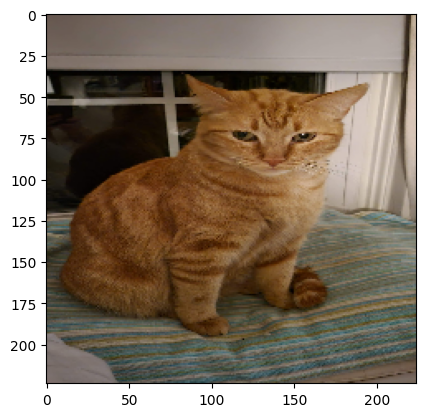

In [6]:
# Load and preprocess an image
def load_and_preprocess_image(image_path):
    # Load the image
    img = load_img(image_path, target_size=(224, 224))

    # Convert the image to a numpy array
    img_array = img_to_array(img)

    # Expand dimensions to fit the model input
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess the image
    img_array = preprocess_input(img_array)

    return img, img_array

# Load and preprocess a sample image
sample_image, processed_image = load_and_preprocess_image('Gigi.jpg')

# Display the sample image
plt.imshow(sample_image)
plt.show()


### Activity 3 Objective: Understanding Data Loading and Preprocessing

In this activity, I observed how an image must be prepared before it can be passed into the VGG16 model. The image was resized to 224 × 224 pixels to match the model's required input size and then converted into a NumPy array.

An additional dimension was added so the image could be treated as a batch containing one image. The `preprocess_input()` function then adjusted the image data into the format expected by VGG16.

This activity showed me that a deep learning model cannot simply use an image file in its original form. The input must be resized, converted to numerical data, and formatted correctly before the model can process it.

In [7]:
# Make predictions
predictions = model.predict(processed_image)

# Decode and print the predictions
decoded_predictions = decode_predictions(predictions, top=3)[0]
print(decoded_predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[('n02123159', 'tiger_cat', np.float32(0.27718168)), ('n02123045', 'tabby', np.float32(0.19774571)), ('n04070727', 'refrigerator', np.float32(0.0960048))]


### Activity 4 Objective: Making Predictions with a Pre-trained Model

In this activity, I used the pre-trained VGG16 model to make predictions on a new image. After the image was preprocessed, `model.predict()` generated prediction scores across the ImageNet classes. The `decode_predictions()` function then translated the model output into readable class labels and displayed the top three predictions.

Using my image of Gigi, the model identified `tiger_cat` and `tabby` as the two highest predictions. This showed how a pre-trained deep learning model can apply what it learned from ImageNet to classify new images that were not part of its original training process.

In [8]:
# Upload button to load images
upload = widgets.FileUpload()
display(upload)

# Button to make predictions
predict_button = widgets.Button(description="Make Prediction")
display(predict_button)

# Function to handle button click
def on_click(change):
    img_data = list(upload.value.values())[0]['content']
    img = Image.open(io.BytesIO(img_data))
    img = img.resize((224, 224))

    # Preprocess and predict
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    predictions = model.predict(img_array)
    decoded_predictions = decode_predictions(predictions, top=3)[0]

    # Display predictions
    print(decoded_predictions)

predict_button.on_click(on_click)


FileUpload(value={}, description='Upload')

Button(description='Make Prediction', style=ButtonStyle())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step
[('n04004767', 'printer', np.float32(0.11995745)), ('n04070727', 'refrigerator', np.float32(0.08540954)), ('n03207941', 'dishwasher', np.float32(0.06568467))]


### Activity 5 Objective: Understanding Model Predictions

In this activity, I observed how the model's predictions can vary depending on the input image. Even when two images contain the same type of object, differences in pose, background, image composition, and preprocessing can affect the model's output.

For example, VGG16 identified Gigi as `tiger_cat` and `tabby`, which were reasonable predictions. However, when I tested an image of Henry, the top predictions included `printer`, `refrigerator`, and `dishwasher`, even though the image clearly showed a cat.

This comparison helped me understand that a deep learning model does not interpret an image the same way a human does. It relies on learned visual features and patterns, so changes in the input can significantly affect the prediction results. This demonstrates why model sensitivity and prediction confidence are important when evaluating deep learning systems.

# Conclusion and Discussion

### Activity 6: Conclusion and Discussion

This lab helped me understand the basic workflow of using a pre-trained deep learning model. VGG16 was already trained on ImageNet, so I did not need to train the model myself. Instead, I provided new images and the model compared the visual features it detected with patterns it had learned during its original training.

Data preprocessing was an important part of this process. The images had to be resized to 224 × 224 pixels, converted into numerical arrays, given a batch dimension, and processed using the format expected by VGG16. This demonstrated that the quality and format of the input data directly affect whether a model can process it correctly.

The prediction results also showed that a model can be sensitive to differences in the input. My image of Gigi produced reasonable predictions such as `tiger_cat` and `tabby`, while an image of Henry produced unexpected predictions including `printer`, `refrigerator`, and `dishwasher`. Even though both images clearly showed cats to me, the model interpreted their visual features differently. This helped me understand that deep learning predictions are based on learned patterns rather than human-like understanding, and that model outputs should be evaluated rather than automatically assumed to be correct.

### Activity 7: Feedback and Self-Assessment

I found this lab helpful because it introduced the workflow of a deep learning model without requiring me to build or train one from scratch. Working with VGG16 made it easier to focus on understanding the model architecture, preprocessing steps, and prediction process.

The most useful part of the lab was testing my own images and comparing the model's predictions. Seeing Gigi classified as a cat while Henry was classified as objects such as a printer, refrigerator, and dishwasher made the limitations and sensitivity of the model much more concrete.

After completing the lab, I feel more confident in my understanding of how a pre-trained image classification model processes input data and produces predictions. I also have a better understanding of why preprocessing is necessary and why model predictions should be evaluated critically rather than accepted automatically.